# Identification of Prognostic Biomarkers in Triple-Negative Breast Cancer Using Differential Gene Expression and Explainable Machine Learning

## Author
Sharmistha Debgoswami

## Date
14th july 2026

## Project Goal
To identify transcriptomic biomarkers associated with Triple-Negative Breast Cancer (TNBC) using RNA sequencing data and interpretable machine learning.

## Notebook
01 - Data Acquisition

In [1]:
# ==========================================
# Project Initialization
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

print("Project Root:")
print(PROJECT_ROOT)

print("\nProject Folders:")

for folder in PROJECT_ROOT.iterdir():
    print(folder.name)

Project Root:
D:\

Project Folders:
!qhlogs.doc
$RECYCLE.BIN
8272b967-cf84-4d1f-bfbe-2bad26c2d6c5 YYYY.jpg
82b153dd-3f81-423b-ad45-1397a99ae029.jpeg
8987595 DNA.png
AMR VESICLES
cfrbackup-ILUFYVFA
dna_8987595.htm
Git
huntingtons
inkscape
ml project
paddydataset.csv.xlsx
PG NOTES.docx
practice set
Project 1 TNBC-Prognostic-Biomarkers
Quick Heal
shap.py steps.docx
Step 1.docx
System Volume Information
THESIS
virtualbox


In [1]:
from pathlib import Path

print("Current Working Directory:")
print(Path.cwd())

Current Working Directory:
D:\Project 1 TNBC-Prognostic-Biomarkers


In [2]:
import os

print("\nFiles in current folder:\n")
print(os.listdir())


Files in current folder:

['.git', '.gitignore', '.ipynb_checkpoints', '.virtual_documents', '01_data_acquisition.ipynb', 'data', 'docs', 'environment', 'environment.yml', 'figures', 'LICENSE', 'Manuscript', 'New folder', 'notebooks', 'README.md', 'references', 'requirements.txt', 'results', 'scripts']


In [1]:
from pathlib import Path
print(Path.cwd())

D:\Project 1 TNBC-Prognostic-Biomarkers


# Data Acquisition

## Objective

Download the TCGA Breast Cancer (BRCA) transcriptomic dataset and inspect its structure before preprocessing.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print("Project Directory:")
print(PROJECT_DIR)

print("\nRaw Data Directory:")
print(RAW_DIR)

Project Directory:
D:\Project 1 TNBC-Prognostic-Biomarkers

Raw Data Directory:
D:\Project 1 TNBC-Prognostic-Biomarkers\data\raw


In [4]:
import pandas as pd

expression_df = pd.read_csv(
    RAW_DIR / "TCGA.BRCA.sampleMap_HiSeqV2.gz",
    sep="\t",
    compression="gzip"
)

expression_df.head()

,sample,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AC-A5XU-01,TCGA-PE-A5DE-01,...,TCGA-A7-A13E-11,TCGA-C8-A8HP-01,TCGA-E9-A5FL-01,TCGA-AC-A2FB-11,TCGA-E2-A15F-01,TCGA-A2-A3XT-01,TCGA-B6-A0X7-01,TCGA-BH-A1EV-11,TCGA-3C-AALJ-01,TCGA-B6-A0X1-01
0,ARHGEF10L,9.5074,7.4346,9.3216,9.0198,9.6417,9.7665,10.0931,9.1524,9.9398,...,9.6265,10.1826,9.9199,9.9090,10.0334,11.5144,10.5745,9.4048,10.9468,10.3164
1,HIF3A,1.5787,3.6607,2.7224,1.3414,0.5819,0.2738,3.6090,0.4738,2.9378,...,8.1546,2.2159,3.8645,8.1872,0.8836,1.3169,4.0696,7.2537,0.9310,2.4191
2,RNF17,0.0000,0.6245,0.5526,0.0000,0.0000,0.8765,0.0000,0.0000,0.0000,...,0.0000,0.0000,3.7305,0.0000,0.0000,1.1329,0.4258,0.0000,0.0000,0.0000
3,RNF10,11.3676,11.9181,11.9665,13.1881,12.0036,11.8118,11.3820,11.5004,12.2055,...,11.9869,12.2653,12.4815,11.8263,12.0135,11.5818,11.8663,11.5460,12.2616,12.1570
4,RNF11,11.1292,13.5273,11.4105,11.0911,11.2545,10.8554,10.7663,10.4358,11.2210,...,11.9344,11.4117,10.4902,11.5754,10.8370,10.2736,10.7644,11.8774,10.7842,11.2420


In [5]:
print("Shape:", expression_df.shape)

Shape: (20530, 1219)


In [6]:
expression_df.columns[:10]

Index(['sample', 'TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01',
       'TCGA-BH-A0BT-01', 'TCGA-A8-A06X-01', 'TCGA-A8-A096-01',
       'TCGA-BH-A0C7-01', 'TCGA-AC-A5XU-01', 'TCGA-PE-A5DE-01'],
      dtype='object')

In [7]:
expression_df.iloc[:5, :5]

,sample,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01
0,ARHGEF10L,9.5074,7.4346,9.3216,9.0198
1,HIF3A,1.5787,3.6607,2.7224,1.3414
2,RNF17,0.0000,0.6245,0.5526,0.0000
3,RNF10,11.3676,11.9181,11.9665,13.1881
4,RNF11,11.1292,13.5273,11.4105,11.0911


In [8]:
expression_df.dtypes

sample              object
TCGA-AR-A5QQ-01    float64
TCGA-D8-A1JA-01    float64
TCGA-BH-A0BQ-01    float64
TCGA-BH-A0BT-01    float64
                    ...   
TCGA-A2-A3XT-01    float64
TCGA-B6-A0X7-01    float64
TCGA-BH-A1EV-11    float64
TCGA-3C-AALJ-01    float64
TCGA-B6-A0X1-01    float64
Length: 1219, dtype: object

In [9]:
expression_df.isnull().sum().sum()

np.int64(0)

In [10]:
expression_df = expression_df.rename(columns={"sample": "Gene"})

In [11]:
expression_df["Gene"].duplicated().sum()

np.int64(0)

In [12]:
expression_df = expression_df.set_index("Gene")

In [13]:
expression_df.head()

,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AC-A5XU-01,TCGA-PE-A5DE-01,TCGA-PE-A5DC-01,...,TCGA-A7-A13E-11,TCGA-C8-A8HP-01,TCGA-E9-A5FL-01,TCGA-AC-A2FB-11,TCGA-E2-A15F-01,TCGA-A2-A3XT-01,TCGA-B6-A0X7-01,TCGA-BH-A1EV-11,TCGA-3C-AALJ-01,TCGA-B6-A0X1-01
Gene,,,,,,,,,,,,,,,,,,,,,
ARHGEF10L,9.5074,7.4346,9.3216,9.0198,9.6417,9.7665,10.0931,9.1524,9.9398,9.6287,...,9.6265,10.1826,9.9199,9.9090,10.0334,11.5144,10.5745,9.4048,10.9468,10.3164
HIF3A,1.5787,3.6607,2.7224,1.3414,0.5819,0.2738,3.6090,0.4738,2.9378,4.1136,...,8.1546,2.2159,3.8645,8.1872,0.8836,1.3169,4.0696,7.2537,0.9310,2.4191
RNF17,0.0000,0.6245,0.5526,0.0000,0.0000,0.8765,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,3.7305,0.0000,0.0000,1.1329,0.4258,0.0000,0.0000,0.0000
RNF10,11.3676,11.9181,11.9665,13.1881,12.0036,11.8118,11.3820,11.5004,12.2055,12.1312,...,11.9869,12.2653,12.4815,11.8263,12.0135,11.5818,11.8663,11.5460,12.2616,12.1570
RNF11,11.1292,13.5273,11.4105,11.0911,11.2545,10.8554,10.7663,10.4358,11.2210,10.8013,...,11.9344,11.4117,10.4902,11.5754,10.8370,10.2736,10.7644,11.8774,10.7842,11.2420


## Expression Data Quality Assessment

In [14]:
expression_df.describe().T

,count,mean,std,min,25%,50%,75%,max
TCGA-AR-A5QQ-01,20530.0,6.458289,4.080824,0.0,2.5772,7.6017,9.699700,18.7069
TCGA-D8-A1JA-01,20530.0,6.196788,4.156713,0.0,1.8909,7.1889,9.622175,17.3728
TCGA-BH-A0BQ-01,20530.0,6.532558,4.024625,0.0,2.9133,7.7018,9.694100,18.0575
TCGA-BH-A0BT-01,20530.0,6.396285,4.064396,0.0,2.4859,7.4771,9.705550,17.2425
TCGA-A8-A06X-01,20530.0,6.195509,4.159198,0.0,1.8007,7.3657,9.635100,17.0628
...,...,...,...,...,...,...,...,...
TCGA-A2-A3XT-01,20530.0,6.409939,4.071828,0.0,2.4525,7.5841,9.712075,16.5289
TCGA-B6-A0X7-01,20530.0,6.495686,4.014227,0.0,2.9112,7.6813,9.715625,18.6516
TCGA-BH-A1EV-11,20530.0,6.692792,3.934542,0.0,3.4058,7.8183,9.752925,16.8841
TCGA-3C-AALJ-01,20530.0,6.440330,4.052720,0.0,2.6870,7.6208,9.683300,17.4642


In [15]:
duplicate_genes = expression_df.index.duplicated().sum()

print(f"Number of duplicate genes: {duplicate_genes}")

Number of duplicate genes: 0


In [16]:
missing_values = expression_df.isna().sum().sum()

print(f"Missing values: {missing_values}")

Missing values: 0


In [17]:
print(f"Number of genes: {expression_df.shape[0]}")
print(f"Number of samples: {expression_df.shape[1]}")

Number of genes: 20530
Number of samples: 1218


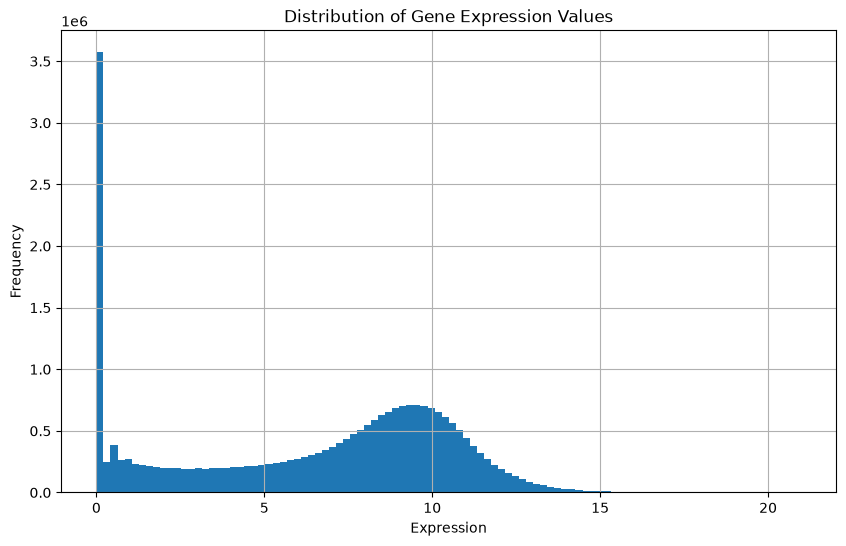

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

expression_df.stack().hist(bins=100)

plt.title("Distribution of Gene Expression Values")
plt.xlabel("Expression")
plt.ylabel("Frequency")

plt.show()

In [19]:
expression_df.to_csv(
    PROCESSED_DIR / "TCGA_BRCA_expression_processed.csv"
)